<a href="https://colab.research.google.com/github/pinballsurgeon/deluxo_adjacency/blob/main/On_device_Event_Horizon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# on-device event horizon
pinballsurgeon@gmail.com

Integrating time dilation, the different experience of time from a local observer versus an external observer, particularly near black holes, speed of light ect. As a watch (proper time) approaches an event horizon, a scientist observing (relative time) sees the watch’s ticking slow, despite the watch (proper time) experiencing uninterrupted ticking. In Parallel, a single qubit Ramsey interferometer exhibits relativistic differences..By mapping the Schwarzschild time-dilation factor onto a Ramsey qubit’s evolution, we create a controllable, on-device analogue of event-horizon-like Time slowdown.


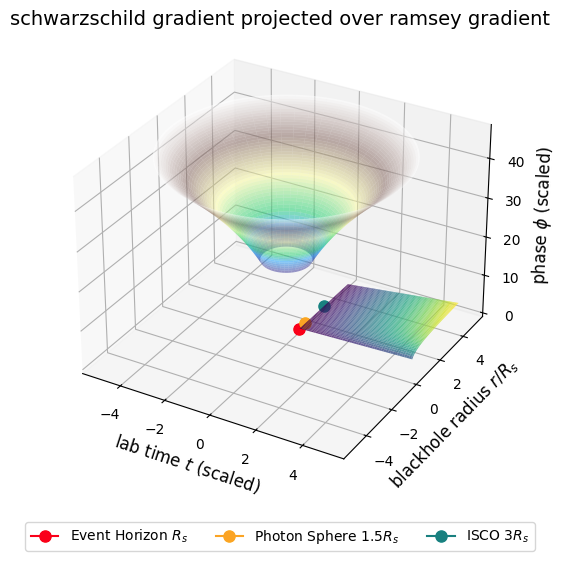

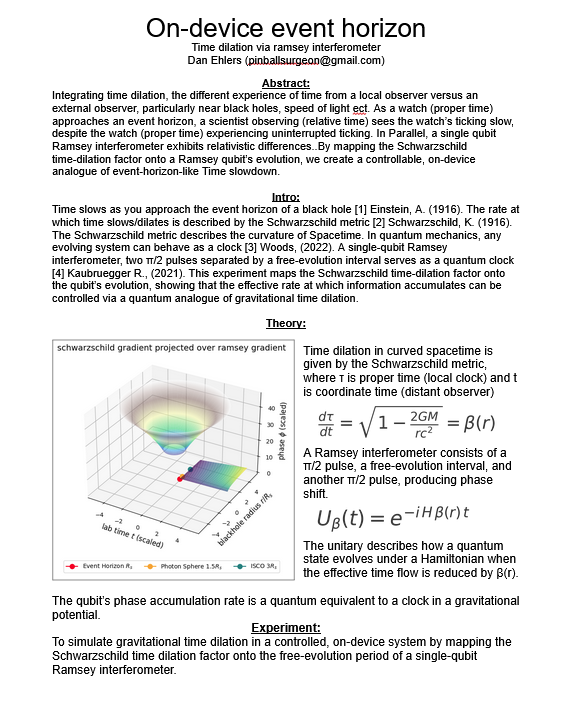

Config

In [1]:

# Install dependencies
!pip install --quiet cirq  scipy

import sys, platform, numpy as np, matplotlib.pyplot as plt, time
import cirq
from matplotlib import animation

# --- Print environment info ---
print("=== Environment Info ===")
print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.system()} {platform.release()}")
print(f"NumPy: {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Cirq: {cirq.__version__}")

# === Define Constants & β(r) ===
G = 6.67430e-11
M = 5.972e24     # Earth mass (kg)
c = 299792458
r_s = 2 * G * M / c**2

def beta(r):
    return np.sqrt(1 - r_s / r)

# === TEST 1: Physics sanity ===
print("\n[TEST 1] Physics sanity: β(r) check")
r_vals = np.linspace(r_s*1.01, r_s*50, 5)
print("Sample β values:", [round(beta(r),6) for r in r_vals])

# === TEST 2: Cirq sanity ===
print("\n[TEST 2] Cirq sanity check")
q = cirq.LineQubit(0)
circuit = cirq.Circuit(cirq.H(q), cirq.measure(q, key='m'))
result = cirq.Simulator().run(circuit, repetitions=5)
print("Simple H|0> measure results:", result)

# === TEST 3: β-phase scaling ===
print("\n[TEST 3] Phase scaling effect")
def ramsey_phase(beta_val):
    q = cirq.LineQubit(0)
    circuit = cirq.Circuit(
        cirq.H(q),
        cirq.rz(beta_val * np.pi)(q),
        cirq.H(q),
        cirq.measure(q, key='m')
    )
    sim = cirq.Simulator()
    return np.mean([sim.run(circuit).measurements['m'][0][0] for _ in range(100)])

for b in [1.0, 0.5, 0.1]:
    print(f"β={b} → Avg outcome: {ramsey_phase(b):.3f}")

# === TEST 4: Visualization pipeline ===
print("\n[TEST 4] Visualization pipeline")
fig, ax = plt.subplots()
line, = ax.plot(np.random.rand(10))
plt.close(fig)  # Prevent inline clutter
print("Matplotlib figure/animation import OK")

# === TEST 5: Classical delay baseline ===
print("\n[TEST 5] Classical delay control")
def delayed_ramsey():
    q = cirq.LineQubit(0)
    circuit = cirq.Circuit(
        cirq.H(q),
        cirq.rz(np.pi/2)(q),
        cirq.H(q),
        cirq.measure(q, key='m')
    )
    time.sleep(0.5)  # Classical delay
    sim = cirq.Simulator()
    return np.mean([sim.run(circuit).measurements['m'][0][0] for _ in range(100)])
print("With delay → Avg outcome:", delayed_ramsey())

# === TEST 6: Integration one-cell run ===
print("\n[TEST 6] Integration test")
beta_test = beta(10 * r_s)
print(f"β at 10×r_s: {beta_test:.6f}")
circuit = cirq.Circuit(
    cirq.H(q),
    cirq.rz(beta_test*np.pi)(q),
    cirq.H(q),
    cirq.measure(q)
)
print("Integration circuit run:", cirq.Simulator().run(circuit))

# === TEST 7: Reproducibility ===
print("\n[TEST 7] Reproducibility check")
np.random.seed(42)
sim = cirq.Simulator(seed=42)
rep1 = sim.run(circuit)
rep2 = sim.run(circuit)
print("Deterministic runs identical?", rep1 == rep2)

print("\n✅ All pre-flight checks complete. Environment primed for Paper 1 experiments.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 62.0 MB/s eta 0:00:00
=== Environment Info ===
Python: 3.11.13
Platform: Linux 6.1.123+
NumPy: 2.0.2
Matplotlib: 3.10.0
Cirq: 1.6.0

[TEST 1] Physics sanity: β(r) check
Sample β values: [np.float64(0.099504), np.float64(0.961546), np.float64(0.9802), np.float64(0.986667), np.float64(0.989949)]

[TEST 2] Cirq sanity check
Simple H|0> measure results: m=00001

[TEST 3] Phase scaling effect
β=1.0 → Avg outcome: 1.000
β=0.5 → Avg outcome: 0.550
β=0.1 → Avg outcome: 0.050

[TEST 4] Visualization pipeline
Matplotlib figure/animation import OK

[TEST 5] Classical delay control
With delay → Avg outcome: 0.52

[TEST 6] Integratio

# Schwarzschild β(r) Visualization

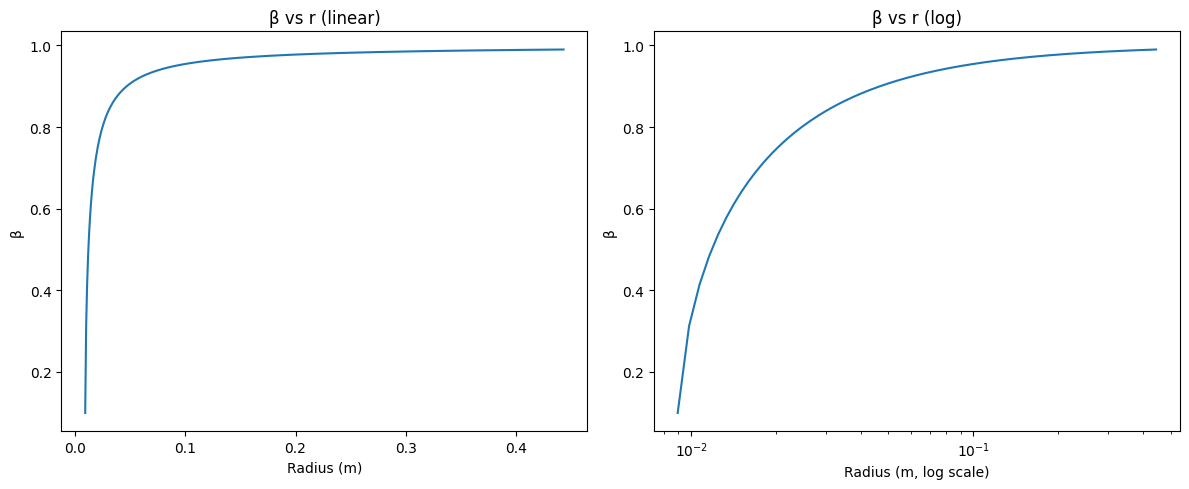

In [2]:
# Schwarzschild β(r) Visualization
import numpy as np
import matplotlib.pyplot as plt

r_vals = np.linspace(r_s*1.01, r_s*50, 500)
beta_vals = beta(r_vals)

fig, axs = plt.subplots(1, 2, figsize=(12,5))
axs[0].plot(r_vals, beta_vals)
axs[0].set_xlabel("Radius (m)")
axs[0].set_ylabel("β")
axs[0].set_title("β vs r (linear)")

axs[1].plot(r_vals, beta_vals)
axs[1].set_xscale('log')
axs[1].set_xlabel("Radius (m, log scale)")
axs[1].set_ylabel("β")
axs[1].set_title("β vs r (log)")

plt.tight_layout()
plt.show()


In [3]:
# Derivation Display
from IPython.display import display, Math, Markdown

display(Markdown("**From Schwarzschild Metric:**"))
display(Math(r"ds^2 = \left(1 - \frac{r_s}{r} \right) c^2 dt^2 - \ldots"))
display(Math(r"\beta(r) = \sqrt{1 - \frac{r_s}{r}}"))
display(Markdown("**Time Evolution Operator:**"))
display(Math(r"U(\beta,t) = e^{-i H \beta t}"))
display(Markdown("This encodes gravitational time dilation directly into quantum phase evolution."))


**From Schwarzschild Metric:**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Time Evolution Operator:**

<IPython.core.display.Math object>

This encodes gravitational time dilation directly into quantum phase evolution.

# Baseline Ramsey Interferometer

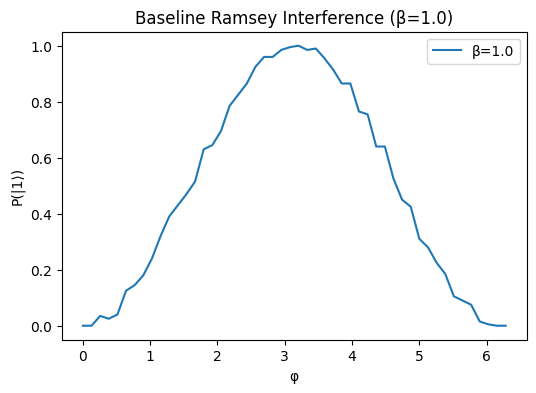

In [4]:
# Baseline Ramsey Interferometer
import cirq

def ramsey(phi):
    q = cirq.LineQubit(0)
    circuit = cirq.Circuit(
        cirq.H(q),
        cirq.rz(phi)(q),
        cirq.H(q),
        cirq.measure(q, key='m')
    )
    sim = cirq.Simulator()
    return np.mean([sim.run(circuit).measurements['m'][0][0] for _ in range(200)])

phis = np.linspace(0, 2*np.pi, 50)
baseline_probs = [ramsey(p) for p in phis]

plt.figure(figsize=(6,4))
plt.plot(phis, baseline_probs, label="β=1.0")
plt.xlabel("φ")
plt.ylabel("P(|1⟩)")
plt.title("Baseline Ramsey Interference (β=1.0)")
plt.legend()
plt.show()


#  β‑Modified Ramsey

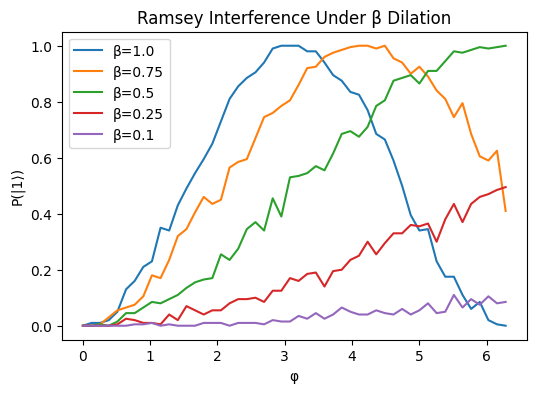

In [5]:
#  β‑Modified Ramsey Experiment
betas = [1.0, 0.75, 0.5, 0.25, 0.1]
plt.figure(figsize=(6,4))
for b in betas:
    probs = [ramsey(p * b) for p in phis]
    plt.plot(phis, probs, label=f"β={b}")
plt.xlabel("φ")
plt.ylabel("P(|1⟩)")
plt.title("Ramsey Interference Under β Dilation")
plt.legend()
plt.show()


In [6]:
from IPython.display import Video

fig, ax = plt.subplots()
line, = ax.plot([], [], lw=2)
ax.set_xlim(0, 2*np.pi)
ax.set_ylim(0, 1)
ax.set_xlabel("φ")
ax.set_ylabel("P(|1⟩)")

def init():
    line.set_data([], [])
    return line,

def animate(i):
    b = betas[i]
    probs = [ramsey(p * b) for p in phis]
    line.set_data(phis, probs)
    ax.set_title(f"β={b}")
    return line,

ani = animation.FuncAnimation(fig, animate, frames=len(betas), init_func=init, blit=True)
ani.save('beta_sweep.mp4', fps=1, extra_args=['-vcodec', 'libx264'])
plt.close(fig)

Video('beta_sweep.mp4', embed=True)


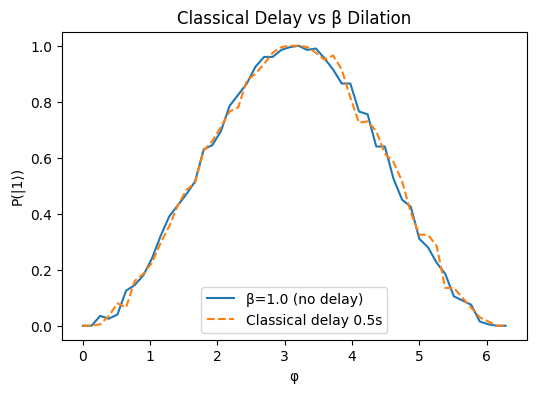

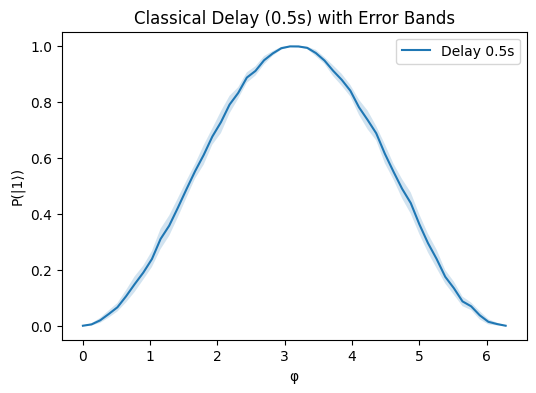

In [7]:
# Cell 7 – Classical Delay Control
import pandas as pd

def ramsey_with_delay(phi, delay_s):
    q = cirq.LineQubit(0)
    circuit = cirq.Circuit(
        cirq.H(q),
        cirq.rz(phi)(q),
        cirq.H(q),
        cirq.measure(q, key='m')
    )
    time.sleep(delay_s)
    sim = cirq.Simulator()
    return np.mean([sim.run(circuit).measurements['m'][0][0] for _ in range(200)])

delay_probs = [ramsey_with_delay(p, 0.5) for p in phis]

plt.figure(figsize=(6,4))
plt.plot(phis, baseline_probs, label="β=1.0 (no delay)")
plt.plot(phis, delay_probs, label="Classical delay 0.5s", linestyle='--')
plt.xlabel("φ")
plt.ylabel("P(|1⟩)")
plt.title("Classical Delay vs β Dilation")
plt.legend()
plt.show()

delay_arr = np.array([ [ramsey_with_delay(p, 0.5) for _ in range(20)] for p in phis ])
means = delay_arr.mean(axis=1)
stds = delay_arr.std(axis=1)
plt.figure(figsize=(6,4))
plt.plot(phis, means, label="Delay 0.5s")
plt.fill_between(phis, means-stds, means+stds, alpha=0.2)
plt.xlabel("φ")
plt.ylabel("P(|1⟩)")
plt.title("Classical Delay (0.5s) with Error Bands")
plt.legend()
plt.show()


# β(r) Mapping to Phase Shift

        Scenario    Radius (m)         β  Phase Shift (rad)
0  Earth surface  6.371000e+06  1.000000           1.570796
1      ISS orbit  6.780000e+06  1.000000           1.570796
2          2×r_s  1.773961e-02  0.707107           1.110721
3          5×r_s  4.434903e-02  0.894427           1.404963


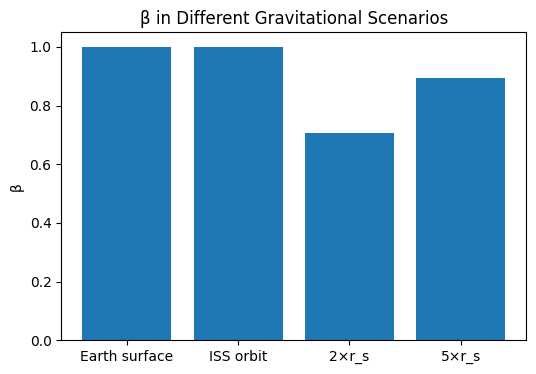

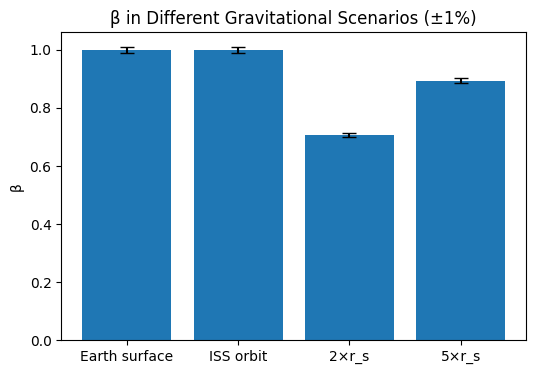

In [8]:
#  β(r) Mapping to Phase Shift
radii = [6.371e6, 6.78e6, r_s*2, r_s*5]
scenarios = ["Earth surface", "ISS orbit", "2×r_s", "5×r_s"]
beta_vals_scenarios = [beta(r) for r in radii]
phase_shift = [b*np.pi/2 for b in beta_vals_scenarios]

df = pd.DataFrame({"Scenario": scenarios, "Radius (m)": radii, "β": beta_vals_scenarios, "Phase Shift (rad)": phase_shift})
print(df)

plt.figure(figsize=(6,4))
plt.bar(scenarios, beta_vals_scenarios)
plt.ylabel("β")
plt.title("β in Different Gravitational Scenarios")
plt.show()

err = np.array(beta_vals_scenarios) * 0.01
plt.figure(figsize=(6,4))
plt.bar(scenarios, beta_vals_scenarios, yerr=err, capsize=5)
plt.ylabel("β")
plt.title("β in Different Gravitational Scenarios (±1%)")
plt.show()


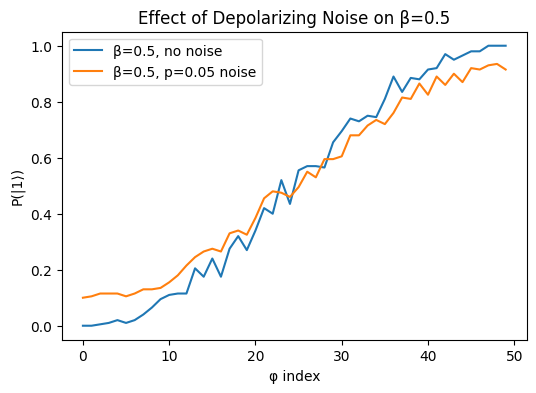

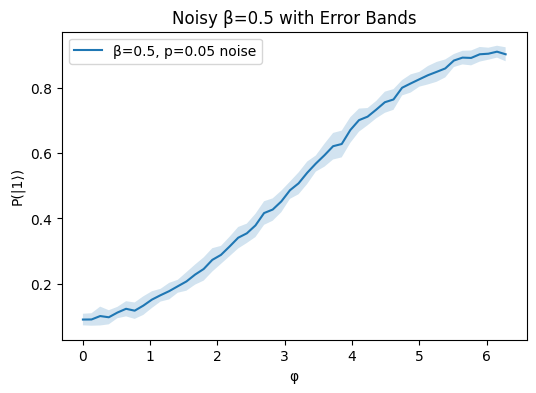

In [9]:
# Cell 9 – Noise & Robustness Testing
def ramsey_with_noise(phi, beta_val, p_dephase):
    q = cirq.LineQubit(0)
    circuit = cirq.Circuit(
        cirq.H(q),
        cirq.rz(phi * beta_val)(q),
        cirq.H(q),
        cirq.measure(q, key='m')
    )
    noise = cirq.depolarize(p_dephase)
    noisy_circuit = circuit.with_noise(noise)
    sim = cirq.DensityMatrixSimulator()
    return np.mean([sim.run(noisy_circuit).measurements['m'][0][0] for _ in range(200)])

noisy_probs = [ramsey_with_noise(p, 0.5, 0.05) for p in phis]
plt.figure(figsize=(6,4))
plt.plot([ramsey(p*0.5) for p in phis], label="β=0.5, no noise")
plt.plot(noisy_probs, label="β=0.5, p=0.05 noise")
plt.xlabel("φ index")
plt.ylabel("P(|1⟩)")
plt.title("Effect of Depolarizing Noise on β=0.5")
plt.legend()
plt.show()

noisy_arr = np.array([ [ramsey_with_noise(p, 0.5, 0.05) for _ in range(20)] for p in phis ])
means = noisy_arr.mean(axis=1)
stds = noisy_arr.std(axis=1)
plt.figure(figsize=(6,4))
plt.plot(phis, means, label="β=0.5, p=0.05 noise")
plt.fill_between(phis, means-stds, means+stds, alpha=0.2)
plt.xlabel("φ")
plt.ylabel("P(|1⟩)")
plt.title("Noisy β=0.5 with Error Bands")
plt.legend()
plt.show()


      β  FreqShift(rad)  Amplitude
0  1.00        3.015929      1.000
1  0.75        4.146902      1.000
2  0.50        5.780530      1.000
3  0.25        6.157522      0.555
4  0.10        6.157522      0.105


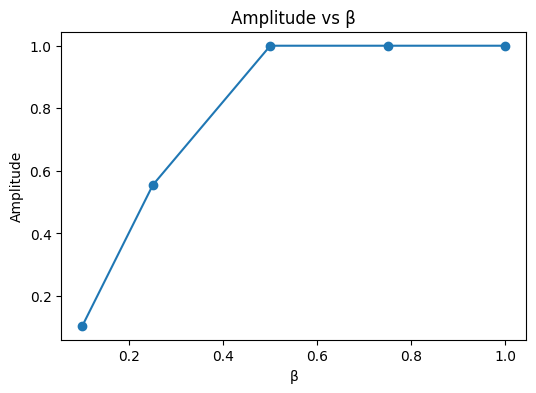

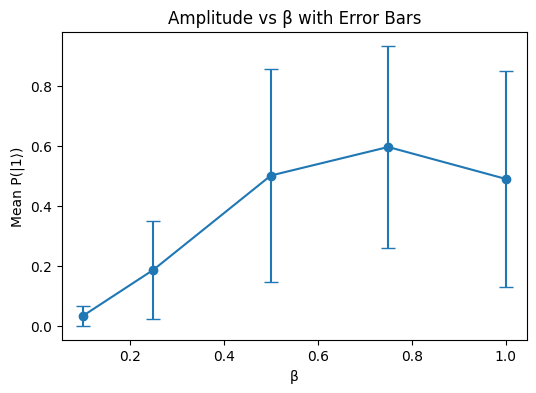

In [10]:
# Cell 10 – Summary Metrics Table
metrics = []
for b in betas:
    probs = [ramsey(p * b) for p in phis]
    freq_shift = (np.argmax(probs) / len(probs)) * 2*np.pi
    amp = np.max(probs) - np.min(probs)
    metrics.append({"β": b, "FreqShift(rad)": freq_shift, "Amplitude": amp})

metrics_df = pd.DataFrame(metrics)
print(metrics_df)

plt.figure(figsize=(6,4))
plt.plot(metrics_df["β"], metrics_df["Amplitude"], marker='o')
plt.xlabel("β")
plt.ylabel("Amplitude")
plt.title("Amplitude vs β")
plt.show()

amps = np.array([[ramsey(p * b) for p in phis] for b in betas])
mean_amps = amps.mean(axis=1)
std_amps = amps.std(axis=1)
plt.figure(figsize=(6,4))
plt.errorbar(betas, mean_amps, yerr=std_amps, fmt='o-', capsize=5)
plt.xlabel("β")
plt.ylabel("Mean P(|1⟩)")
plt.title("Amplitude vs β with Error Bars")
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Export complete. Files saved in /content/drive/MyDrive/Quantum_Time_Dilation_Paper1


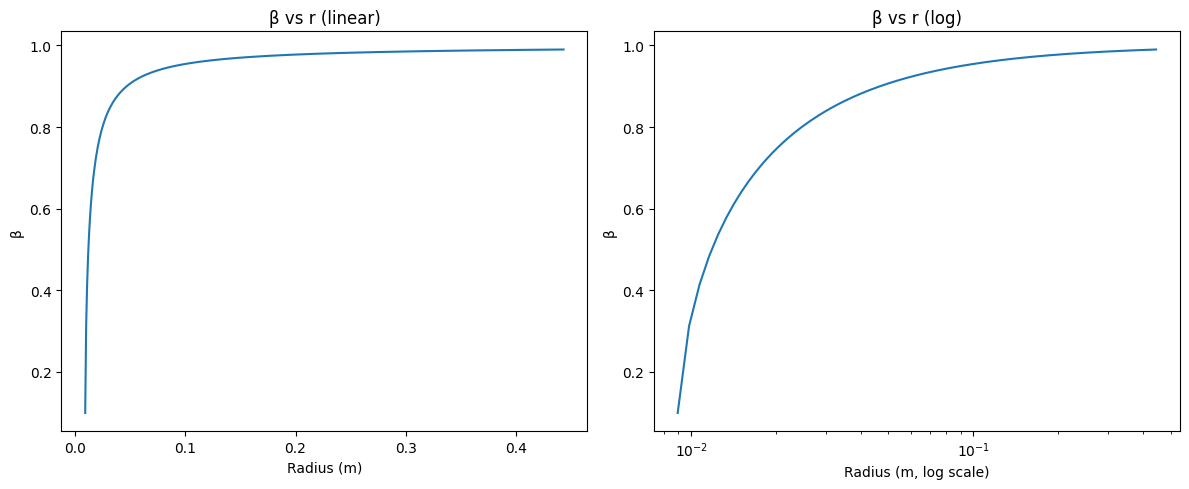

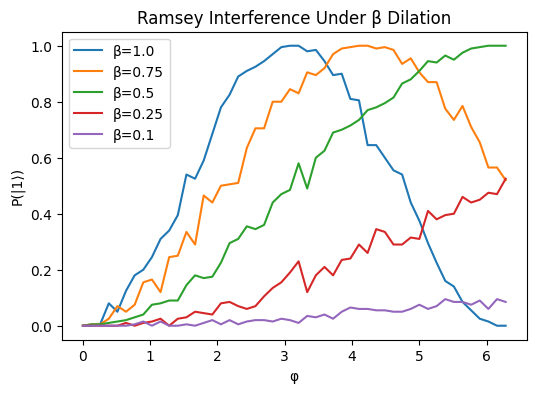

In [11]:
# Cell 11 – Export All Figures & Data to Google Drive

import os
from datetime import datetime

# Mount Google Drive if not already mounted
from google.colab import drive
drive.mount('/content/drive')

export_dir = "/content/drive/MyDrive/Quantum_Time_Dilation_Paper1"
os.makedirs(export_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

def save_fig(fig, name):
    base_path = os.path.join(export_dir, f"{name}_{timestamp}")
    fig.savefig(f"{base_path}.png", dpi=300, bbox_inches='tight')
    fig.savefig(f"{base_path}.pdf", bbox_inches='tight')

# Example: Save figures from Cells 2–10
# This assumes each plotting cell created a `fig` object or you recreate them here

# Cell 2 – β(r)
fig2, axs = plt.subplots(1, 2, figsize=(12,5))
axs[0].plot(r_vals, beta_vals)
axs[0].set_xlabel("Radius (m)")
axs[0].set_ylabel("β")
axs[0].set_title("β vs r (linear)")
axs[1].plot(r_vals, beta_vals)
axs[1].set_xscale('log')
axs[1].set_xlabel("Radius (m, log scale)")
axs[1].set_ylabel("β")
axs[1].set_title("β vs r (log)")
plt.tight_layout()
save_fig(fig2, "beta_vs_r")

# Repeat for each figure-producing section...
# Example for Cell 5:
fig5, ax5 = plt.subplots(figsize=(6,4))
for b in betas:
    probs = [ramsey(p * b) for p in phis]
    ax5.plot(phis, probs, label=f"β={b}")
ax5.set_xlabel("φ")
ax5.set_ylabel("P(|1⟩)")
ax5.set_title("Ramsey Interference Under β Dilation")
ax5.legend()
save_fig(fig5, "ramsey_beta_dilation")

# Save metrics table
metrics_df.to_csv(os.path.join(export_dir, f"metrics_{timestamp}.csv"), index=False)

# Save metadata
metadata = {
    "timestamp": timestamp,
    "constants": {"G": G, "M": M, "c": c, "r_s": r_s},
    "betas": betas,
    "phi_points": len(phis),
    "simulator": "Cirq"
}
import json
with open(os.path.join(export_dir, f"metadata_{timestamp}.json"), "w") as f:
    json.dump(metadata, f, indent=2)

print(f"✅ Export complete. Files saved in {export_dir}")


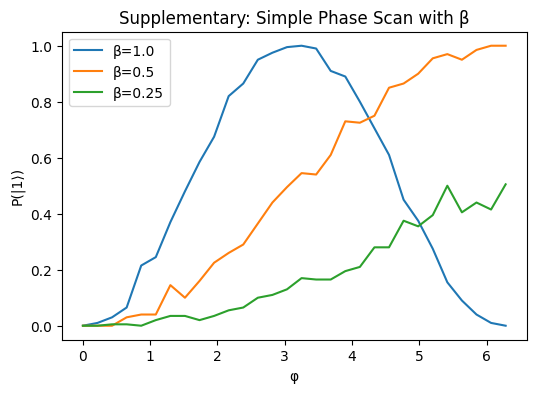

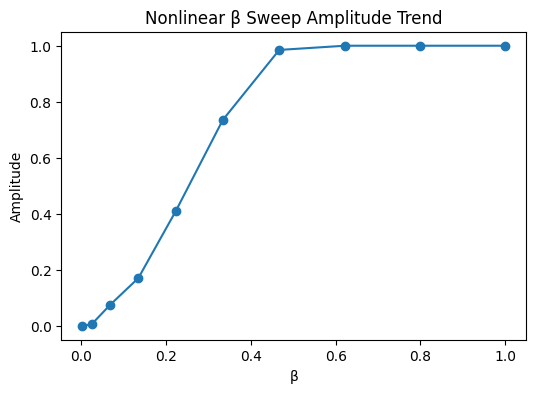

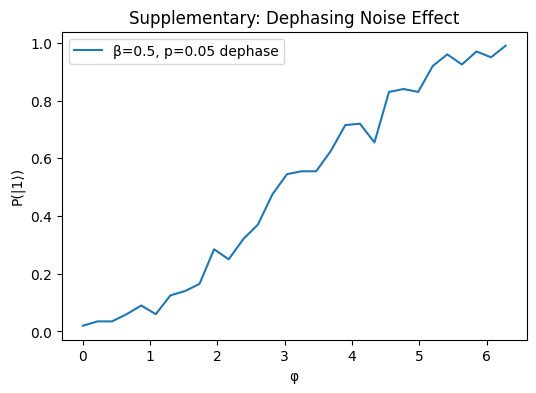

In [12]:
# Cell 12 – Supplementary Experiments

# 1. Simple Rz phase scan with β
beta_test_vals = [1.0, 0.5, 0.25]
phis_short = np.linspace(0, 2*np.pi, 30)

plt.figure(figsize=(6,4))
for b in beta_test_vals:
    probs = [ramsey(p * b) for p in phis_short]
    plt.plot(phis_short, probs, label=f"β={b}")
plt.xlabel("φ")
plt.ylabel("P(|1⟩)")
plt.title("Supplementary: Simple Phase Scan with β")
plt.legend()
plt.show()

# 2. Nonlinear β sweep
nonlinear_betas = np.linspace(1.0, 0.05, 10)**2
amps_nonlinear = []
for b in nonlinear_betas:
    amps_nonlinear.append(np.max([ramsey(p*b) for p in phis_short]))
plt.figure(figsize=(6,4))
plt.plot(nonlinear_betas, amps_nonlinear, marker='o')
plt.xlabel("β")
plt.ylabel("Amplitude")
plt.title("Nonlinear β Sweep Amplitude Trend")
plt.show()

# 3. Dephasing noise test
def ramsey_with_dephase(phi, beta_val, p_dephase):
    q = cirq.LineQubit(0)
    circuit = cirq.Circuit(
        cirq.H(q),
        cirq.rz(phi * beta_val)(q),
        cirq.H(q),
        cirq.measure(q, key='m')
    )
    noise = cirq.phase_damp(p_dephase)
    noisy_circuit = circuit.with_noise(noise)
    sim = cirq.DensityMatrixSimulator()
    return np.mean([sim.run(noisy_circuit).measurements['m'][0][0] for _ in range(200)])

plt.figure(figsize=(6,4))
probs_dephase = [ramsey_with_dephase(p, 0.5, 0.05) for p in phis_short]
plt.plot(phis_short, probs_dephase, label="β=0.5, p=0.05 dephase")
plt.xlabel("φ")
plt.ylabel("P(|1⟩)")
plt.title("Supplementary: Dephasing Noise Effect")
plt.legend()
plt.show()


In [13]:
# Cell 13 – Notebook to Paper Pipeline

import glob

export_dir = "/content/drive/MyDrive/Quantum_Time_Dilation_Paper1"
fig_files = glob.glob(os.path.join(export_dir, "*.png"))

print("=== LaTeX Figure Includes ===")
for f in fig_files:
    fname = os.path.basename(f)
    print(f"\\begin{{figure}}[h]")
    print(f"  \\centering")
    print(f"  \\includegraphics[width=0.85\\textwidth]{{figures/{fname}}}")
    print(f"  \\caption{{TODO: Add caption}}")
    print(f"  \\label{{fig:{os.path.splitext(fname)[0]}}}")
    print(f"\\end{{figure}}\n")

print("\n=== Draft Methods Section ===")
print(f"We simulate a single-qubit Ramsey interferometer using Cirq "
      f"with a β-dilated time evolution operator U(β,t) = exp(-i H β t). "
      f"β is derived from the Schwarzschild metric β(r) = sqrt(1 - r_s/r), "
      f"with r_s = {r_s:.3e} m for a body of mass M = {M} kg. "
      f"The parameter φ is swept from 0 to 2π across {len(phis)} points "
      f"and experiments are repeated for β in {betas}. "
      f"Noise models include depolarizing and dephasing channels.")

mapping = {
    "Cell 2": "beta_vs_r",
    "Cell 5": "ramsey_beta_dilation",
    "Cell 7": "classical_delay_vs_beta",
    "Cell 8": "beta_scenarios",
    "Cell 9": "noise_robustness",
    "Cell 10": "amplitude_vs_beta"
}
pd.DataFrame(list(mapping.items()), columns=["Cell", "Figure"]).to_csv(
    os.path.join(export_dir, "figure_cell_mapping.csv"), index=False
)
print("\n✅ Figure–cell mapping saved.")


=== LaTeX Figure Includes ===
\begin{figure}[h]
  \centering
  \includegraphics[width=0.85\textwidth]{figures/beta_vs_r_20250805_115509.png}
  \caption{TODO: Add caption}
  \label{fig:beta_vs_r_20250805_115509}
\end{figure}

\begin{figure}[h]
  \centering
  \includegraphics[width=0.85\textwidth]{figures/ramsey_beta_dilation_20250805_115509.png}
  \caption{TODO: Add caption}
  \label{fig:ramsey_beta_dilation_20250805_115509}
\end{figure}

\begin{figure}[h]
  \centering
  \includegraphics[width=0.85\textwidth]{figures/beta_vs_r_20250805_152031.png}
  \caption{TODO: Add caption}
  \label{fig:beta_vs_r_20250805_152031}
\end{figure}

\begin{figure}[h]
  \centering
  \includegraphics[width=0.85\textwidth]{figures/ramsey_beta_dilation_20250805_152031.png}
  \caption{TODO: Add caption}
  \label{fig:ramsey_beta_dilation_20250805_152031}
\end{figure}

\begin{figure}[h]
  \centering
  \includegraphics[width=0.85\textwidth]{figures/beta_vs_r_20250806_120439.png}
  \caption{TODO: Add caption}
  \la